# Comparaison `best` vs `small2` vs `small2_30ig` — N runs × 2 datasets

Trois architectures évaluées :
- **best** : modèle PBIP complet (NT2 + MegaDNA + DNABERT2 pour bact & phage)
- **small2** : MegaDNA bact + NT2 phage (ex-`idk`)
- **small2_30ig** : small2 restreint aux 194 dims sélectionnées par IG

Procédure : pour chaque config, **N=6 entraînements indépendants** sur le train set PredPhi, puis évaluation sur deux jeux de test :

- **Test PredPhi** : `data/perphect-data/predphi/predphi_test_dataset.csv` (in-distribution)
- **Généralisation (all)** : `data/perphect-data/all/couples_df.csv` (out-of-distribution)

On rapporte la **moyenne ± écart-type** sur les N runs.

Pour `small2_30ig`, la sélection des dimensions est figée (`bact_dims.npy` + `phage_dims.npy` déjà sauvés), seul le classifieur est réentraîné.

In [ ]:
%cd ../..
!pwd

/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code
/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code


/home/nathan/anaconda3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import time
import copy
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    matthews_corrcoef, confusion_matrix,
)

# PyTorch >= 2.6 : torch.load() utilise weights_only=True par défaut, ce qui
# fait échouer le chargement des checkpoints MegaDNA (modèle complet picklé).
_orig_torch_load = torch.load
def _torch_load_compat(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _orig_torch_load(*args, **kwargs)
torch.load = _torch_load_compat

from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput
from pbi_utils.config_parser import InputConfig
from main import (
    parse_config, reduce_dimensionality, make_dataset,
    train_nn_model,
    create_embeddings_bacteria, create_embeddings_phages,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cuda


## 1. Jeu de données commun

On définit un `InputConfig` qui pointe vers les 3 CSV à charger.
Le `PerphectDataInput` se chargera de les lire.

In [3]:
input_train = InputConfig(
    bacteria_df="data/perphect-data/predphi/bacteria_sequences.csv",
    phages_df="data/perphect-data/predphi/bacteriophages_sequences.csv",
    couples_df="data/perphect-data/predphi/predphi_train_dataset.csv",
)
input_predphi = InputConfig(
    bacteria_df="data/perphect-data/predphi/bacteria_sequences.csv",
    phages_df="data/perphect-data/predphi/bacteriophages_sequences.csv",
    couples_df="data/perphect-data/predphi/predphi_test_dataset.csv",
)
input_all = InputConfig(
    bacteria_df="data/perphect-data/all/bacteria_df.csv",
    phages_df="data/perphect-data/all/phages_df.csv",
    couples_df="data/perphect-data/all/couples_df.csv",
)

_, _, train_couples   = PerphectDataInput(input_paths=input_train).load()
_, _, predphi_couples = PerphectDataInput(input_paths=input_predphi).load()
_, _, all_couples     = PerphectDataInput(input_paths=input_all).load()
print(f"Train PredPhi : {len(train_couples)} couples")
print(f"Test PredPhi  : {len(predphi_couples)} couples")
print(f"All           : {len(all_couples)} couples")

[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_train_dataset.csv
[INFO] Reading csv files...
[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_test_dataset.csv
[INFO] Reading csv files...
[INFO] Perphect input files will be read from data/perphect-data/all/bacteria_df.csv, data/perphect-data/all/phages_df.csv and data/perphect-data/all/couples_df.csv
[INFO] Reading csv files...
Train PredPhi : 5702 couples
Test PredPhi  : 1236 couples
All           : 7720 couples


## 2. Fonctions utilitaires

- `load_dataset_for_model` charge un dataset (embeddings concaténés) pour la config
- `train_fresh` instancie un classifieur neuf et l'entraîne sur le train set
- `evaluate` retourne les métriques sur un dataset donné
- `select_dims_in_dataset` slice les embeddings aux dimensions sélectionnées

In [4]:
from main import create_embeddings_bacteria, create_embeddings_phages

def load_dataset_for_model(config, input_paths, embeddings_dir=None):
    """Charge le dataset (embeddings concaténés) pour la config donnée."""
    cfg = copy.deepcopy(config)
    cfg.input_perphect = input_paths
    emb_dir = embeddings_dir if embeddings_dir is not None else cfg.embeddings_dir
    output_manager = H5pyEmbeddingsManager(emb_dir)

    bact_df, phage_df, couples_df = PerphectDataInput(input_paths=input_paths).load()
    create_embeddings_bacteria(
        bacteria_models=cfg.bacteria_embedding_models,
        compute_bacteria_embeddings=cfg.compute_bacteria_embeddings,
        bacteria_df=bact_df, output_manager=output_manager,
    )
    create_embeddings_phages(
        phages_models=cfg.phages_embedding_models,
        compute_phages_embeddings=cfg.compute_phages_embeddings,
        phages_df=phage_df, output_manager=output_manager,
    )

    bact_names  = [m.name() for m in cfg.bacteria_embedding_models]
    phage_names = [m.name() for m in cfg.phages_embedding_models]
    ds = make_dataset(couples_df, bact_names, phage_names, output_manager, device)
    ds = reduce_dimensionality(
        ds, cfg.training_config.reduce_dimensionality, cfg.output_dir,
        cfg.training_config.n_components_bacteria,
        cfg.training_config.n_components_phages,
    )
    return ds


def train_fresh(config, train_ds):
    """Instancie un classifieur neuf et l'entraîne."""
    bact_size  = len(train_ds["bacterium_embedding"].iloc[0])
    phage_size = len(train_ds["phage_embedding"].iloc[0])
    model = config.classifier(bact_size, phage_size, **config.classifier_params).to(device)
    train_nn_model(train_ds, model, config.training_config, device=device, verbose=0)
    model.eval()
    return model


def evaluate(model, ds):
    preds, probs, labels = [], [], []
    model.eval()
    with torch.no_grad():
        for _, row in ds.iterrows():
            b = row["bacterium_embedding"].unsqueeze(0).to(device)
            p = row["phage_embedding"].unsqueeze(0).to(device)
            out = model(b, p)
            prob = torch.softmax(out, dim=1)[0]
            preds.append(int(prob.argmax().item()))
            probs.append(float(prob[1].item()))
            labels.append(int(row["interaction_type"]))
    preds, labels = np.array(preds), np.array(labels)
    return {
        "mcc":       matthews_corrcoef(labels, preds),
        "f1":        f1_score(labels, preds, zero_division=0),
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
    }


def select_dims_in_dataset(ds, bact_dims, phage_dims):
    """Slice les embeddings aux dims sélectionnées."""
    ds2 = ds.copy()
    ds2["bacterium_embedding"] = [e[bact_dims].float() for e in ds["bacterium_embedding"]]
    ds2["phage_embedding"]     = [e[phage_dims].float() for e in ds["phage_embedding"]]
    return ds2

## 3. Chargement des configs et datasets

Chaque modèle a besoin de 3 datasets : train PredPhi (pour entraîner), test PredPhi (in-distribution), all (généralisation). On charge tout une fois puis on réutilise dans la boucle d'entraînement.

Pour `small2_30ig`, on réutilise les datasets de `small2` et on slice aux dimensions IG-sélectionnées.

In [5]:
config_best = parse_config(config_path="output/pbip/best/training_config.yaml")

ds_best_train   = load_dataset_for_model(config_best, input_train,        embeddings_dir="data/embeddings-pbip")
ds_best_predphi = load_dataset_for_model(config_best, input_predphi,      embeddings_dir="data/embeddings-pbip")
ds_best_all     = load_dataset_for_model(config_best, input_all,          embeddings_dir="data/embeddings")

print(f"[best]    train={len(ds_best_train)}  test_predphi={len(ds_best_predphi)}  test_all={len(ds_best_all)}")
print(f"          bact_size={len(ds_best_train['bacterium_embedding'].iloc[0])}  phage_size={len(ds_best_train['phage_embedding'].iloc[0])}")

[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 16384
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 16384
[INFO] Configuration loaded from output/pbip/best/training_config.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=0, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=True k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TopBottomTruncateStrategy(), overlap=0, model_name='nucleotide-transform

Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Loading 5702 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Loading 5702 embeddings for model DNABERT2-BottomTruncateStrategy-ov0-maxlen16384 from data/embeddings-pbip


...

[DEBUG] Loading 7720 embeddings for model MegaDNA-TopBottomTruncateStrategy-concat-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Loading 7720 embeddings for model DNABERT2-TKPert-concat-J16-g20-ov0-maxlen16384 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 2500
[DEBUG] Final embedding size (phages): 15752
[best]    train=5702  test_predphi=1236  test_all=7720
          bact_size=2500  phage_size=15752


### Datasets pour `small2`

In [6]:
config_small2 = parse_config(config_path="output/pbip/small2/training_config.yaml")

ds_small2_train   = load_dataset_for_model(config_small2, input_train,        embeddings_dir="data/embeddings-pbip")
ds_small2_predphi = load_dataset_for_model(config_small2, input_predphi,      embeddings_dir="data/embeddings-pbip")
ds_small2_all     = load_dataset_for_model(config_small2, input_all,          embeddings_dir="data/embeddings")

print(f"[small2]  train={len(ds_small2_train)}  test_predphi={len(ds_small2_predphi)}  test_all={len(ds_small2_all)}")
print(f"          bact_size={len(ds_small2_train['bacterium_embedding'].iloc[0])}  phage_size={len(ds_small2_train['phage_embedding'].iloc[0])}")

[INFO] Configuration loaded from output/pbip/small2/training_config.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=False epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=True k_folds_cv=1 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TruncateStrategy(), overlap=0, model_name='nucleotide-transformer-v2-250m-multi-species', get_layer='last')], compute_phages_embeddings=[True], bacteria_embedding_models=[MegaDNA(merging_s

Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Loading 5702 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
[INFO] Embeddings will be stored or read from data/embeddings-pbip
[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_test_dataset.csv
[INFO] Reading csv files...
[INFO] Creating embeddings for 0 bacteria models...
[DEBUG] Skipping bacteria model MegaDNA-TruncateStrategy-concat-ov0 (use_cached_embeddings=True).
[INFO] Creating embeddings for 0 phages models...
[DEBUG] Skipping phage model NT2-TruncateStrategy-250M-ov0 (use_cached_embeddings=True).
[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 1236 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip


...

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
[INFO] Embeddings will be stored or read from data/embeddings
[INFO] Perphect input files will be read from data/perphect-data/all/bacteria_df.csv, data/perphect-data/all/phages_df.csv and data/perphect-data/all/couples_df.csv
[INFO] Reading csv files...
[INFO] Creating embeddings for 0 bacteria models...
[DEBUG] Skipping bacteria model MegaDNA-TruncateStrategy-concat-ov0 (use_cached_embeddings=True).
[INFO] Creating embeddings for 0 phages models...
[DEBUG] Skipping phage model NT2-TruncateStrategy-250M-ov0 (use_cached_embeddings=True).
[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 7720 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Loading 7720 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
[small2]  train=5702  test_predphi=1236  test_all=7720
          bact_size=964  phage_size=768


### Sélection des dims pour `small2_30ig`

In [7]:
ig30_dir = os.path.join(config_small2.output_dir, "ig80")
bact_dims_30  = np.load(os.path.join(ig30_dir, "bact_dims.npy"))
phage_dims_30 = np.load(os.path.join(ig30_dir, "phage_dims.npy"))
print(f"Dims sélectionnées : bact {len(bact_dims_30)} | phage {len(phage_dims_30)}")

ds_ig30_train   = select_dims_in_dataset(ds_small2_train,   bact_dims_30, phage_dims_30)
ds_ig30_predphi = select_dims_in_dataset(ds_small2_predphi, bact_dims_30, phage_dims_30)
ds_ig30_all     = select_dims_in_dataset(ds_small2_all,     bact_dims_30, phage_dims_30)
print(f"[small2_30ig] train={len(ds_ig30_train)}  bact_size={len(ds_ig30_train['bacterium_embedding'].iloc[0])}  phage_size={len(ds_ig30_train['phage_embedding'].iloc[0])}")

Dims sélectionnées : bact 402 | phage 503
[small2_30ig] train=5702  bact_size=402  phage_size=503


## 4. Entraînement et évaluation, N runs

In [ ]:
N_RUNS = 10

model_setups = {
    "best":         (config_best,   ds_best_train,   ds_best_predphi,   ds_best_all),
    "small2":       (config_small2, ds_small2_train, ds_small2_predphi, ds_small2_all),
    "small2_30ig":  (config_small2, ds_ig30_train,   ds_ig30_predphi,   ds_ig30_all),
}

records = []
for name, (cfg, ds_tr, ds_pp, ds_all) in model_setups.items():
    print(f"\n=== {name} ({N_RUNS} runs) ===")
    for run in range(N_RUNS):
        t0 = time.time()
        model = train_fresh(cfg, ds_tr)
        m_pp  = evaluate(model, ds_pp)
        m_all = evaluate(model, ds_all)
        for split, m in [("test_predphi", m_pp), ("test_all", m_all)]:
            records.append({"model": name, "run": run, "split": split, **m})
        print(f"  run {run+1}/{N_RUNS} ({time.time()-t0:.1f}s) | "
              f"predphi MCC={m_pp['mcc']:.3f} F1={m_pp['f1']:.3f}  ||  "
              f"all MCC={m_all['mcc']:.3f} F1={m_all['f1']:.3f}")

df_runs = pd.DataFrame(records)
#df_runs.to_csv("analysis/models_comparison_runs.csv", index=False)
print(f"\n{len(df_runs)} mesures sauvegardées dans analysis/models_comparison_runs.csv")


=== best (10 runs) ===
  run 1/10 (11.8s) | predphi MCC=0.375 F1=0.649  ||  all MCC=-0.131 F1=0.264
  run 2/10 (11.6s) | predphi MCC=0.439 F1=0.699  ||  all MCC=-0.139 F1=0.251
  run 3/10 (11.5s) | predphi MCC=0.440 F1=0.715  ||  all MCC=-0.172 F1=0.265
  run 4/10 (11.3s) | predphi MCC=0.462 F1=0.704  ||  all MCC=-0.167 F1=0.260
  run 5/10 (11.3s) | predphi MCC=0.389 F1=0.654  ||  all MCC=-0.140 F1=0.257
  run 6/10 (11.6s) | predphi MCC=0.453 F1=0.725  ||  all MCC=-0.149 F1=0.256
  run 7/10 (12.0s) | predphi MCC=0.436 F1=0.702  ||  all MCC=-0.112 F1=0.269
  run 8/10 (11.8s) | predphi MCC=0.487 F1=0.734  ||  all MCC=-0.183 F1=0.259
  run 9/10 (11.7s) | predphi MCC=0.423 F1=0.679  ||  all MCC=-0.170 F1=0.255
  run 10/10 (11.5s) | predphi MCC=0.347 F1=0.640  ||  all MCC=-0.195 F1=0.259

=== small2 (10 runs) ===
  run 1/10 (8.6s) | predphi MCC=0.554 F1=0.772  ||  all MCC=0.313 F1=0.571
  run 2/10 (8.6s) | predphi MCC=0.578 F1=0.786  ||  all MCC=0.302 F1=0.567
  run 3/10 (8.8s) | predphi M

In [9]:
metrics_cols = ["mcc", "f1", "accuracy", "precision", "recall"]

agg = (
    df_runs.groupby(["model", "split"])[metrics_cols]
           .agg(["mean", "std"])
           .round(4)
)

agg

mcc              f1         accuracy          \
                            mean     std    mean     std     mean     std   
model       split                                                           
best        test_all     -0.1557  0.0260  0.2595  0.0054   0.4628  0.0243   
            test_predphi  0.4249  0.0428  0.6901  0.0330   0.7104  0.0224   
small2      test_all      0.3173  0.0195  0.5739  0.0098   0.5766  0.0236   
            test_predphi  0.5599  0.0308  0.7763  0.0221   0.7794  0.0158   
small2_30ig test_all      0.3207  0.0268  0.5749  0.0132   0.5741  0.0297   
            test_predphi  0.5568  0.0275  0.7715  0.0193   0.7778  0.0142   

                         precision          recall          
                              mean     std    mean     std  
model       split                                           
best        test_all        0.2329  0.0093  0.2938  0.0152  
            test_predphi    0.7407  0.0189  0.6477  0.0527  
small2      test_all        0.4240  0.0135  0.8893  0.0199  
            test_predphi    0.7862  0.0088  0.7680  0.0436  
small2_30ig test_all        0.4235  0.0184  0.8974  0.0333  
            test_predphi    0.7929  0.0103  0.7523  0.0374

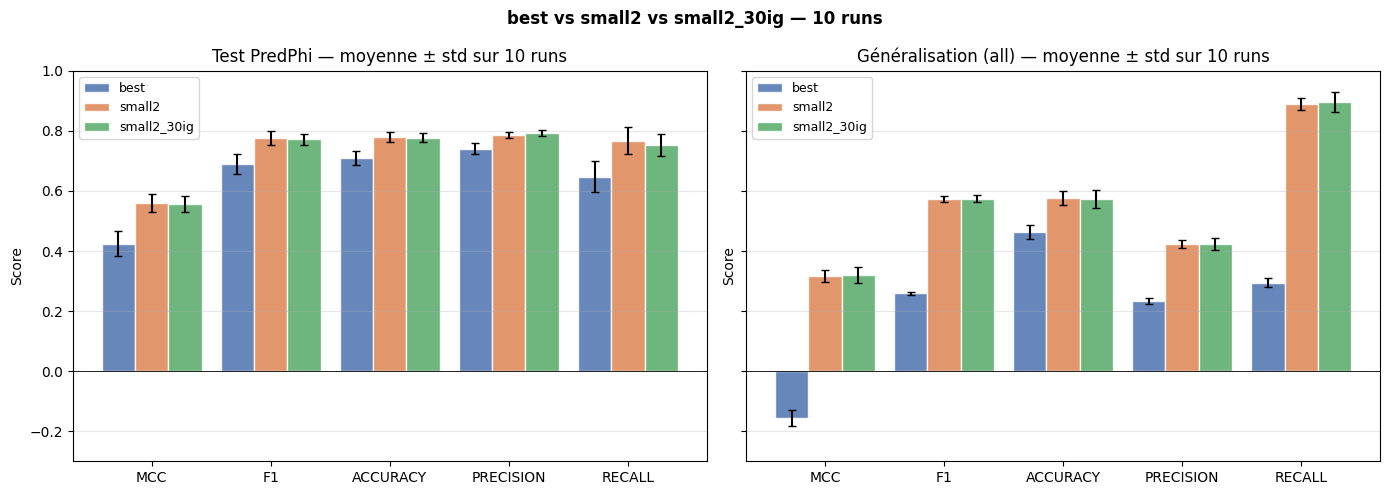

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

colors = {"best": "#4C72B0", "small2": "#DD8452", "small2_30ig": "#55A868"}
metrics_to_plot = ["mcc", "f1", "accuracy", "precision", "recall"]
x = np.arange(len(metrics_to_plot))
w = 0.28

for ax, split, title in [
    (axes[0], "test_predphi", "Test PredPhi"),
    (axes[1], "test_all",     "Généralisation (all)"),
]:
    for i, name in enumerate(model_setups.keys()):
        sub = df_runs[(df_runs["model"] == name) & (df_runs["split"] == split)]
        means = [sub[m].mean() for m in metrics_to_plot]
        stds  = [sub[m].std()  for m in metrics_to_plot]
        ax.bar(x + (i - 1) * w, means, w, yerr=stds, label=name,
               color=colors[name], alpha=0.85, capsize=3, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metrics_to_plot])
    ax.axhline(0, color="black", lw=0.6)
    ax.set_ylabel("Score")
    ax.set_ylim(-0.3, 1)
    ax.set_title(f"{title} — moyenne ± std sur {N_RUNS} runs")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle(f"best vs small2 vs small2_30ig — {N_RUNS} runs", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()